# Lecture 10e. KNN vs. other classifiers (reference notebook)

*Optional / Career-track* &mdash; read **after** the mandatory `lec_10a` / `lec_10b` / `lec_10c`.

KNN is rarely the **only** tool you would reach for in a real classification project. Most teams sketch two or three candidate classifiers, fit them quickly, and pick the one whose assumptions match the data and the deployment constraints. This notebook is a **decision-reflex builder**: by the end you should recognise within seconds &mdash; just from the shape and size of a dataset &mdash; when logistic regression, decision trees, or SVM is likely to beat KNN.

Three things to keep in mind as you read:

1. This is a **reference notebook**, modelled on `lec_09f_other_clustering_algos.ipynb`. The code cells are deliberately tiny &mdash; just enough to show the call signature. Each classifier gets a proper, careful treatment in the next three lectures (see the forward references in each section).
2. We use the **iris** dataset throughout so we can run all four classifiers on the same axes. Iris is famously easy &mdash; every reasonable classifier scores around 95% on it. That is intentional: it forces the discussion onto *when to prefer*, not *which wins on this toy*.
3. We compare KNN against three alternatives: **logistic regression**, **decision trees** (with a one-line nod to random forests), and **SVM** with an RBF kernel. There are many more &mdash; gradient-boosted trees, naive Bayes, neural networks &mdash; but these three cover the bulk of everyday tabular classification.

Lecture forward-references used below:

- **Lecture 11** &mdash; regression, train/validation/test split, the bias-variance trade-off.
- **Lecture 12** &mdash; logistic regression in depth, naive Bayes, SVM.
- **Lecture 13** &mdash; `Pipeline`, hyperparameter grids, cross-validation, ensembles (random forests, gradient boosting).

## §1 The classifier zoo &mdash; a 60-second mental model

Before any code, here is the comparison table to memorise. Each row is one classifier; each column is one axis you should be checking before you choose.

| Classifier | Decision boundary | Scaling required? | Interpretable? | Fit cost | Predict cost |
| --- | --- | --- | --- | --- | --- |
| **KNN** | Piecewise (Voronoi cells) | **Yes** &mdash; distance-based | Low (no global model) | O(1) &mdash; just stores the data | **O(N · d)** per query |
| **Logistic regression** | Linear (in the feature space) | Helpful for convergence + regularisation | High &mdash; one coefficient per feature | O(N · d) per epoch | **O(d)** per query |
| **Decision tree** | Axis-aligned rectangles | **No** &mdash; splits are scale-invariant | High &mdash; the tree is the explanation | O(N · d · log N) | **O(depth)** per query |
| **SVM (RBF kernel)** | Smooth non-linear | **Yes** &mdash; distance-based | Low (kernel space) | **O(N² to N³)** | O(#support vectors · d) |

Read it as a checklist:

- **Is the boundary roughly linear?** &rarr; start with logistic regression.
- **Are features mixed types and unscaled, and does the stakeholder want to read off rules?** &rarr; decision tree.
- **Is the boundary curvy but smooth, and the dataset moderate (a few thousand rows)?** &rarr; SVM with RBF kernel.
- **Do you want a strong baseline with almost no assumptions, and you can afford slow predictions?** &rarr; KNN.

The single biggest *operational* difference is the last column: KNN pays its cost at **prediction time** (it scans the whole training set for every query), while logistic regression and decision trees pay almost nothing at prediction time. For a model serving thousands of requests per second, that one column often decides the choice.

### Shared setup &mdash; iris, train/test split, scaler

We load iris once and split it once (with `random_state=42`) so every classifier below sees identical training and test data. KNN and SVM need scaled features (they are distance-based); logistic regression converges more cleanly with scaled features; decision trees do not need scaling at all. We fit a `StandardScaler` on the training data and reuse it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [2]:
iris = load_iris(as_frame=True)
X = iris.data           # 4 features: sepal length/width, petal length/width
y = iris.target         # 3 classes: setosa, versicolor, virginica
X.shape, y.shape

((150, 4), (150,))

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y,
)
X_train.shape, X_test.shape

((105, 4), (45, 4))

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Baseline: KNN with K=5 on scaled features. We will compare every other
# classifier below against this number.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_accuracy = accuracy_score(y_test, knn.predict(X_test_scaled))
print(f"KNN (k=5) test accuracy: {knn_accuracy:.3f}")

KNN (k=5) test accuracy: 0.911


## §2 Logistic regression &mdash; the linear baseline you should always try first

Despite the name, **logistic regression is a classifier**, not a regressor. It models the log-odds of each class as a *linear* combination of the features. The decision boundary in feature space is therefore a hyperplane (a line in 2D, a plane in 3D). Training learns one coefficient per feature per class, plus an intercept &mdash; tiny model, instant predictions, and the coefficients are directly inspectable.

**When to prefer over KNN:**

- The decision boundary is **roughly linear** &mdash; or you can engineer features (interactions, polynomials) that make it so.
- You need **probability calibration**: logistic regression's `predict_proba` is, by construction, an estimate of the class probability, not a vote count. KNN can return probabilities too, but they are coarse (with K=5, the only possible values are 0, 0.2, 0.4, 0.6, 0.8, 1.0).
- The dataset is **huge** &mdash; KNN's prediction cost grows linearly with the training set size (O(N · d) per query), while logistic regression's is O(d) regardless of how many training rows you had.
- You need an **interpretable** model: the sign and magnitude of each coefficient tell you which features push the prediction toward which class.

Forward-reference: logistic regression is covered properly in **lecture 12**, and the loss-function machinery (sigmoid, cross-entropy) carries over directly to neural networks in **lectures 14&ndash;16**.

&rarr; [scikit-learn `LogisticRegression` docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) &middot; [User Guide: linear models](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)

In [6]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_accuracy = accuracy_score(y_test, logreg.predict(X_test_scaled))
print(f"Logistic regression test accuracy: {logreg_accuracy:.3f}")
print(f"KNN (k=5)            test accuracy: {knn_accuracy:.3f}")

Logistic regression test accuracy: 0.911
KNN (k=5)            test accuracy: 0.911


In [7]:
# One coefficient per (class, feature). The sign tells you in which
# direction that feature pushes the prediction toward that class.
coef_table = pd.DataFrame(
    logreg.coef_, columns=iris.feature_names, index=iris.target_names,
)
coef_table.round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.08,0.95,-1.70,-1.60
versicolor,0.47,-0.45,-0.12,-0.79
virginica,0.60,-0.51,1.82,2.40


## §3 Decision trees (and the leap to random forests)

A **decision tree** classifies by asking a sequence of simple yes/no questions about one feature at a time ("is petal length &gt; 2.45 cm?"). Each question is a *split*. The training algorithm greedily picks the split that best separates the classes (lowest Gini impurity or highest information gain) and recurses on each side. The final tree is a flowchart that a human can literally read top to bottom.

**When to prefer over KNN:**

- **Features are mixed types** (categorical + numeric) and/or have **wildly different scales**. Trees are scale-invariant &mdash; you can feed in `age_in_years` and `salary_in_euros` together and the splits don't care.
- **Interpretability is a hard requirement** (regulated industries, medical decisions, anything that has to be auditable). The tree *is* the explanation.
- The boundary is **piecewise-constant / axis-aligned**: thresholding rules like "if income &gt; 50k and age &lt; 30 then ..." are exactly what trees learn natively.

**The leap to random forests:** a single deep tree overfits badly. A **random forest** fits many trees on bootstrap samples of the data (each tree only sees a random subset of features at each split) and averages their predictions. You give up the interpretability of one tree, but in return you get one of the most reliable off-the-shelf tabular classifiers in existence. Random forests &mdash; and their cousin **gradient-boosted trees** (XGBoost / LightGBM) &mdash; are covered in **lecture 13**.

&rarr; [scikit-learn `DecisionTreeClassifier` docs](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) &middot; [User Guide: decision trees](https://scikit-learn.org/stable/modules/tree.html) &middot; [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [8]:
# Note: we feed the *unscaled* features. Trees do not need scaling.
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
tree_accuracy = accuracy_score(y_test, tree.predict(X_test))
print(f"Decision tree (max_depth=3) test accuracy: {tree_accuracy:.3f}")
print(f"KNN (k=5)                   test accuracy: {knn_accuracy:.3f}")

Decision tree (max_depth=3) test accuracy: 0.978
KNN (k=5)                   test accuracy: 0.911


In [9]:
# Trees expose feature importances directly. Higher value = used in
# more (or higher-impact) splits.
importance_table = pd.Series(
    tree.feature_importances_, index=iris.feature_names,
).sort_values(ascending=False)
importance_table.round(3)

petal length (cm)    0.551
petal width (cm)     0.449
sepal width (cm)     0.000
sepal length (cm)    0.000
dtype: float64

## §4 Support Vector Machines (RBF kernel)

A **Support Vector Machine** finds the *widest possible margin* between classes. In its linear form it learns a hyperplane (like logistic regression, but optimised for margin rather than likelihood). With a **kernel** &mdash; most commonly the Radial Basis Function (RBF) kernel &mdash; SVM can learn smooth non-linear boundaries without you having to engineer the non-linear features by hand. The kernel implicitly maps your data into a higher-dimensional space where a linear separator exists.

**When to prefer over KNN:**

- The decision boundary is **non-linear but smooth** (curved, blob-like, not jagged).
- You have a **moderate sample size** &mdash; a few hundred to a few tens of thousands of rows. SVM's training cost scales between O(N²) and O(N³), so it gets uncomfortable above ~100k rows. KNN flips the trade-off: training is O(1), but prediction is O(N) &mdash; different bottlenecks.
- The number of features is **larger than the number of samples** (`d > N`). SVMs handle high-dimensional sparse data &mdash; text classification with TF-IDF features is a classic SVM win.

**Watch out for:** the two hyperparameters `C` (regularisation strength) and `gamma` (RBF kernel width) interact strongly. You almost always tune them together with cross-validation &mdash; see **lecture 13** on grid search and pipelines. And like KNN, SVM is distance-based &mdash; **feature scaling is mandatory**.

&rarr; [scikit-learn `SVC` docs](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) &middot; [User Guide: support vector machines](https://scikit-learn.org/stable/modules/svm.html)

In [10]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm.fit(X_train_scaled, y_train)
svm_accuracy = accuracy_score(y_test, svm.predict(X_test_scaled))
print(f"SVM (RBF kernel) test accuracy: {svm_accuracy:.3f}")
print(f"KNN (k=5)        test accuracy: {knn_accuracy:.3f}")

SVM (RBF kernel) test accuracy: 0.933
KNN (k=5)        test accuracy: 0.911


In [11]:
# SVM keeps only the points on or inside the margin as 'support vectors'.
# Prediction cost scales with this number, not with the full training size.
n_support_vectors = svm.n_support_.sum()
n_training_points = X_train.shape[0]
print(f"Support vectors kept: {n_support_vectors} / {n_training_points}")

Support vectors kept: 40 / 105


## §5 A unified comparison on iris

Now we fit all four classifiers on the same train/test split and read off the test accuracies side-by-side. Iris is too easy for the differences to matter much &mdash; that is the honest closing note. On harder, messier datasets (the kind you will meet in lectures 11&ndash;13 and on the final assignment), the *gap* between these classifiers grows, and the choice of which one to deploy actually decides whether the project ships.

In [12]:
# Map each classifier to the feature matrix it expects (scaled vs. raw).
classifiers = {
    "KNN (k=5)":            (knn,    X_test_scaled),
    "Logistic regression":  (logreg, X_test_scaled),
    "Decision tree":        (tree,   X_test),
    "SVM (RBF)":            (svm,    X_test_scaled),
}

results = pd.DataFrame(
    [
        {"classifier": name, "test_accuracy": accuracy_score(y_test, model.predict(X_eval))}
        for name, (model, X_eval) in classifiers.items()
    ]
)
results

,classifier,test_accuracy
0,KNN (k=5),0.911111
1,Logistic regression,0.911111
2,Decision tree,0.977778
3,SVM (RBF),0.933333


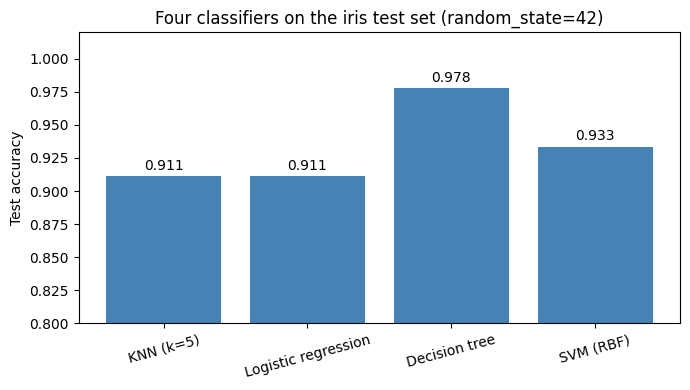

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results["classifier"], results["test_accuracy"], color="steelblue")
ax.set_ylim(0.80, 1.02)
ax.set_ylabel("Test accuracy")
ax.set_title("Four classifiers on the iris test set (random_state=42)")
for x, v in enumerate(results["test_accuracy"]):
    ax.text(x, v + 0.005, f"{v:.3f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**The honest closing note.** On iris, all four classifiers land within a few percentage points of each other &mdash; usually around 0.93&ndash;0.98. That is *not* a failure of the comparison; it is the message. Iris's classes are nearly linearly separable in petal-length/petal-width space, so any reasonable algorithm finds the answer. The interesting questions are not "which is most accurate on iris?" but:

- Which one would still run fast enough if the dataset had 10 million rows?
- Which one would give the regulator a defensible explanation per prediction?
- Which one would survive a feature whose scale is 1000&times; another feature's, with no scaling step?

Those answers come straight off the table in §1. That is the reflex this notebook exists to build.

## §6 Where to go next

**In this course:**

- **Lecture 11** &mdash; linear regression, the train/validation/test split done properly, bias-variance trade-off. Sets up the loss-function vocabulary you need for logistic regression.
- **Lecture 12** &mdash; logistic regression, naive Bayes, and SVM done end-to-end (not just one cell each).
- **Lecture 13** &mdash; `sklearn.pipeline.Pipeline`, hyperparameter grids with `GridSearchCV` / `RandomizedSearchCV`, ensemble methods (random forests, gradient boosting).

**External references (prefer the sklearn docs over blog posts):**

- [Supervised learning algorithms in scikit-learn](https://scikit-learn.org/stable/supervised_learning.html) &mdash; the master index.
- [Classifier comparison on toy 2D datasets](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html) &mdash; the canonical "which algorithm picks up which boundary shape" gallery. The closest classification analogue to the clustering comparison plot referenced in `lec_09f`.
- [Choosing the right estimator (the sklearn cheat-sheet flowchart)](https://scikit-learn.org/stable/machine_learning_map.html) &mdash; ten-second routing from data shape to candidate algorithm.
- [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html) &mdash; the meta-skill: not leaking test data, not re-fitting the scaler, not comparing classifiers on different splits.